# SCRIPT CHẠY THỐNG KÊ KẾT QUẢ

Có tổng cộng 4 nhóm phương pháp:
- Phương pháp machine learning, kí hiệu là `ml`
- Phương pháp encoder-only, kí hiểu là `encoder`
- Phương pháp encoder-decoder, kí hiệu là `seq2seq`
- Phương pháp dùng gọi API LLM, kí hiệu là `api-llm`
- Phương pháp decoder-only, kí hiệu là `decoder`


$\to$ Kết quả điền vào từng nhóm phương pháp

Cấu trúc input bao gồm:
- Precision và Recll của từng nhãn
- `f1`: Test-macro F1 trên tập test high-aug
- `name`: Tên phương pháp cụ thể
- `dataset`: Loại data dùng để train, bao gồm `high-med`, `high`, `full`
- `method`: Phương pháp (được định nghĩa ở trên)
Ví dụ:
```python
{
    'SUPPORTED': [precision, recall], 'NEI': [precision, recall], 'REFUTED': [precision, recall],
    'f1': chỉ_số_macro_f1
    'name': tên_phương_pháp_cụ_thể, 
    'dataset': data_dùng_để_train,
    'method': tên_nhóm_phương pháp,
}
```
Đặt tên ngắn cho phương pháp ở dictionary `SHORT_NAMES`



In [50]:
main_method = ['ml', 'encoder', 'seq2seq', 'api-llm']

In [51]:
# Đặt tên ngắn của phương pháp cụ thể
SHORT_NAMES = {
    'fastest+logistic regression': 'FastText+LR',
    'word2vec + logistic regression': 'W2V+LR',
    'sbert+logistic regression encode 3 evidence': 'SBERT+LR(3ev)',
    'sbert+logistic regression (encode từng evidence)': 'SBERT+LR(1ev)',
    'sbert+xgboost': 'SBERT+XGB',
    'phobert+phase+cls': 'PhoBERT+CLS',
    'phobert+phase+max-pool': 'PhoBERT+MaxPool',
    'phobert+phase+mean-pool': 'PhoBERT+MeanPool',
    'bartpho': 'bartpho'
}

### Kết quả phương pháp học máy truyền thống
Bao gồm: fastest, word2vec, sbert cùng với logistic regression, xgboost

In [52]:
ml_res = [
    {
        'SUPPORTED': [0.4569, 0.4000], 'NEI': [0.4745, 0.5852], 'REFUTED': [0.5360, 0.4722], 
        'f1': 0.4842,
        'name': 'fastest+logistic regression', 'dataset': 'high-aug',
        'cm': [[106, 109, 50], [59, 158, 53], [67, 66, 119]],
        'method': 'ml'
    },
    {
        'SUPPORTED': [0.4797, 0.4453], 'NEI': [0.4808, 0.5111], 'REFUTED': [0.5000, 0.5040], 
        'f1': 0.4862,
        'name': 'word2vec + logistic regression', 'dataset': 'high-aug',
        'cm': [[118, 91, 56], [61, 138, 71], [67, 58, 127]],
        'method': 'ml'
    },
    {
        'SUPPORTED': [0.5540, 0.5811], 'NEI': [0.5985, 0.5963], 'REFUTED': [0.6083, 0.5794], 
        'f1': 0.5860,
        'name': 'sbert+logistic regression encode 3 evidence', 'dataset': 'high-aug',
        'cm': [[154, 68, 43], [58, 161, 51], [66, 40, 146]],
        'method': 'ml'
    },
    {
        'SUPPORTED': [0.5551, 0.5321], 'NEI': [0.5744, 0.6148], 'REFUTED': [0.6066, 0.5873], 
        'f1': 0.5780,
        'name': 'sbert+logistic regression (encode từng evidence)', 'dataset': 'high-aug',
        'cm': [[141, 75, 49], [57, 166, 47], [56, 48, 148]],
        'method': 'ml'
    },
    {
        'SUPPORTED': [0.5528, 0.5132], 'NEI': [0.5892, 0.6481], 'REFUTED': [0.6475, 0.6270], 
        'f1': 0.5956,
        'name': 'sbert+xgboost', 'dataset': 'high-aug',
        'cm': [[138, 80, 49], [58, 175, 37], [52, 42, 158]],
        'method': 'ml'
    },
]

### Kết qủa phương pháp encoder
Bao gồm phoBERT

In [53]:
encoder_res = [
    # { 
    #     'SUPPORTED': [0.8058, 0.7303], 'NEI': [0.8431, 0.8221], 'REFUTED': [ 0.5686, 0.6744 ], 
    #     'f1': 0.6879,
    #     'name': 'phobert+phase+cls', 'dataset': 'high',
    #     'cm': [[195, 16, 56], [18, 231, 32], [29, 27, 116]],
    #     'method': 'encoder'
    # },
    {
        'SUPPORTED': [ 0.7737, 0.7094 ], 'NEI': [ 0.8375, 0.8593], 'REFUTED': [ 0.7378, 0.7817 ], 
        'f1': 0.7825,
        'name': 'phobert+phase+cls', 'dataset': 'high-aug',
        'cm': [[188, 27, 50], [18, 232, 20], [37, 18, 197]],
        'method': 'encoder'
    },
    {
        'SUPPORTED': [ 0.7799, 0.7025 ], 'NEI': [ 0.8655, 0.8222], 'REFUTED': [ 0.5175, 0.6743 ], 
        'f1': 0.7227,
        'name': 'phobert+phase+cls', 'dataset': 'high-aug',
        'cm': [[248, 31, 74], [28, 296, 36], [42, 15, 118]],
        'method': 'encoder'
    },
    # {
    #     'SUPPORTED': [0.7122, 0.7228], 'NEI': [0.8216, 0.7046], 'REFUTED': [0.5529, 0.6686], 
    #     'f1': 0.6938,
    #     'name': 'phobert+phase+cls', 'dataset': 'full',
    #     'cm': [[193, 20, 54], [44, 198, 39], [34, 23, 115]],
    #     'method': 'encoder',
    # },
    # {
    #     'SUPPORTED': [0.58, 0.5843], 'NEI': [0.5876, 0.5730], 'REFUTED': [0.5, 0.5116], 
    #     'f1': 
    #     'name': 'phobert+phase+max-pool', 'dataset': 'high-aug',
    #     'cm': [[156, 66, 45], [76, 161, 44], [37, 47, 88]]
    # },
    # {
    #     'SUPPORTED': [0.6015, 0.5993], 'NEI': [0.6085, 0.5587], 'REFUTED': [0.4184, 0.4767], 
    #     'name': 'phobert+phase+max-pool', 'dataset': 'high',
    #     'cm': [[160, 47, 60], [70, 157, 54], [36, 54, 82]]
    # },
    # {
    #     # Thí nghiệm phobert+phase+mean-pool ban đầu
    #     'SUPPORTED': [0.6432, 0.5516], 'NEI': [0.4387, 0.5407], 'REFUTED': [0.5281, 0.5281], 
    #     'name': 'phobert+phase+mean-pool', 'dataset': 'high-aug',
    #     'cm': [[141, 53, 73], [80, 155, 46], [46, 33, 93]]
    # },
    # {
    #     # Thí nghiệm phobert+phase+mean-pool ban đầu
    #     'SUPPORTED': [0.5281, 0.5281], 'NEI': [0.6432, 0.5516], 'REFUTED': [0.4387, 0.5407], 
    #     'name': 'phobert+phase+mean-pool', 'dataset': 'full',
    #     'cm': [[141, 53, 73], [80, 155, 46], [46, 33, 93]]
    # },
   
    
]

### Kết quả phương pháp Seq2Seq
Bao gồm: BartPHO

In [54]:
seq2seq = [
    {
        'SUPPORTED': [0.67, 0.61],  
        'NEI': [0.75, 0.67],        
        'REFUTED': [0.54, 0.74],   
        'name': 'bartpho-word', 
        'dataset': 'high-aug',
        'f1': 0.6566,
        'cm': [
            [217, 49, 87],  
            [93, 242, 25],  
            [13, 33, 129]   
        ],
        'method': 'seq2seq'
    },
]

### Kết quả phương pháp api-llm
Bao gồm: mistral, gemini-2.5-flash

In [55]:
api_llm = []

### Kết quả phương pháp decoder-only
Bao gồm: gemme-3-4b-it, qwen-1.5-instruct 

In [ ]:
decoder_res = [
    {
        'SUPPORTED': [0.92, 0.87], 'NEI': [0.96, 0.86], 'REFUTED': [0.73, 0.96], 
        'name': 'gemma-3-4b-it', 'dataset': 'high-aug',
        'f1': 0.8786,
        'cm': [[308, 36, 9], [23, 311, 26], [4, 3, 168]],
        'method': 'decoder'
    },
    {
        'SUPPORTED': [0.87, 0.90], 'NEI': [0.92, 0.90], 'REFUTED': [0.80, 0.79], 
        'name': 'qwen-2.5-1.5b-instruct', 'dataset': 'high-aug',
        'f1': 0.8645,
        'cm': [[318, 13, 22], [24, 323, 13], [22, 14, 139]],
        'method': 'decoder'
    },
]

In [57]:
all_res = ml_res + encoder_res + seq2seq + api_llm + decoder_res

  Confusion Matrix Analysis — Vietnamese Fact Verification

📊 Macro-F1 Summary (top 5):
                 model  dataset  macro_f1  accuracy
         gemma-3-4b-it high-aug  0.886765  0.886261
qwen-2.5-1.5b-instruct high-aug  0.864483  0.878378
           PhoBERT+CLS high-aug  0.782524  0.783990
           PhoBERT+CLS high-aug  0.722703  0.745495
          bartpho-word high-aug  0.656602  0.662162

🔍 Mô hình nhầm REFUTED nhiều nhất:
  FastText+LR [high-aug]  — REFUTED error rate: 52.78%
  W2V+LR [high-aug]  — REFUTED error rate: 49.60%
  SBERT+LR(3ev) [high-aug]  — REFUTED error rate: 42.06%
  SBERT+LR(1ev) [high-aug]  — REFUTED error rate: 41.27%
  SBERT+XGB [high-aug]  — REFUTED error rate: 37.30%

🎨 Đang vẽ các biểu đồ... (7 figures)

✅  Saved: fig1_confusion_matrices.png


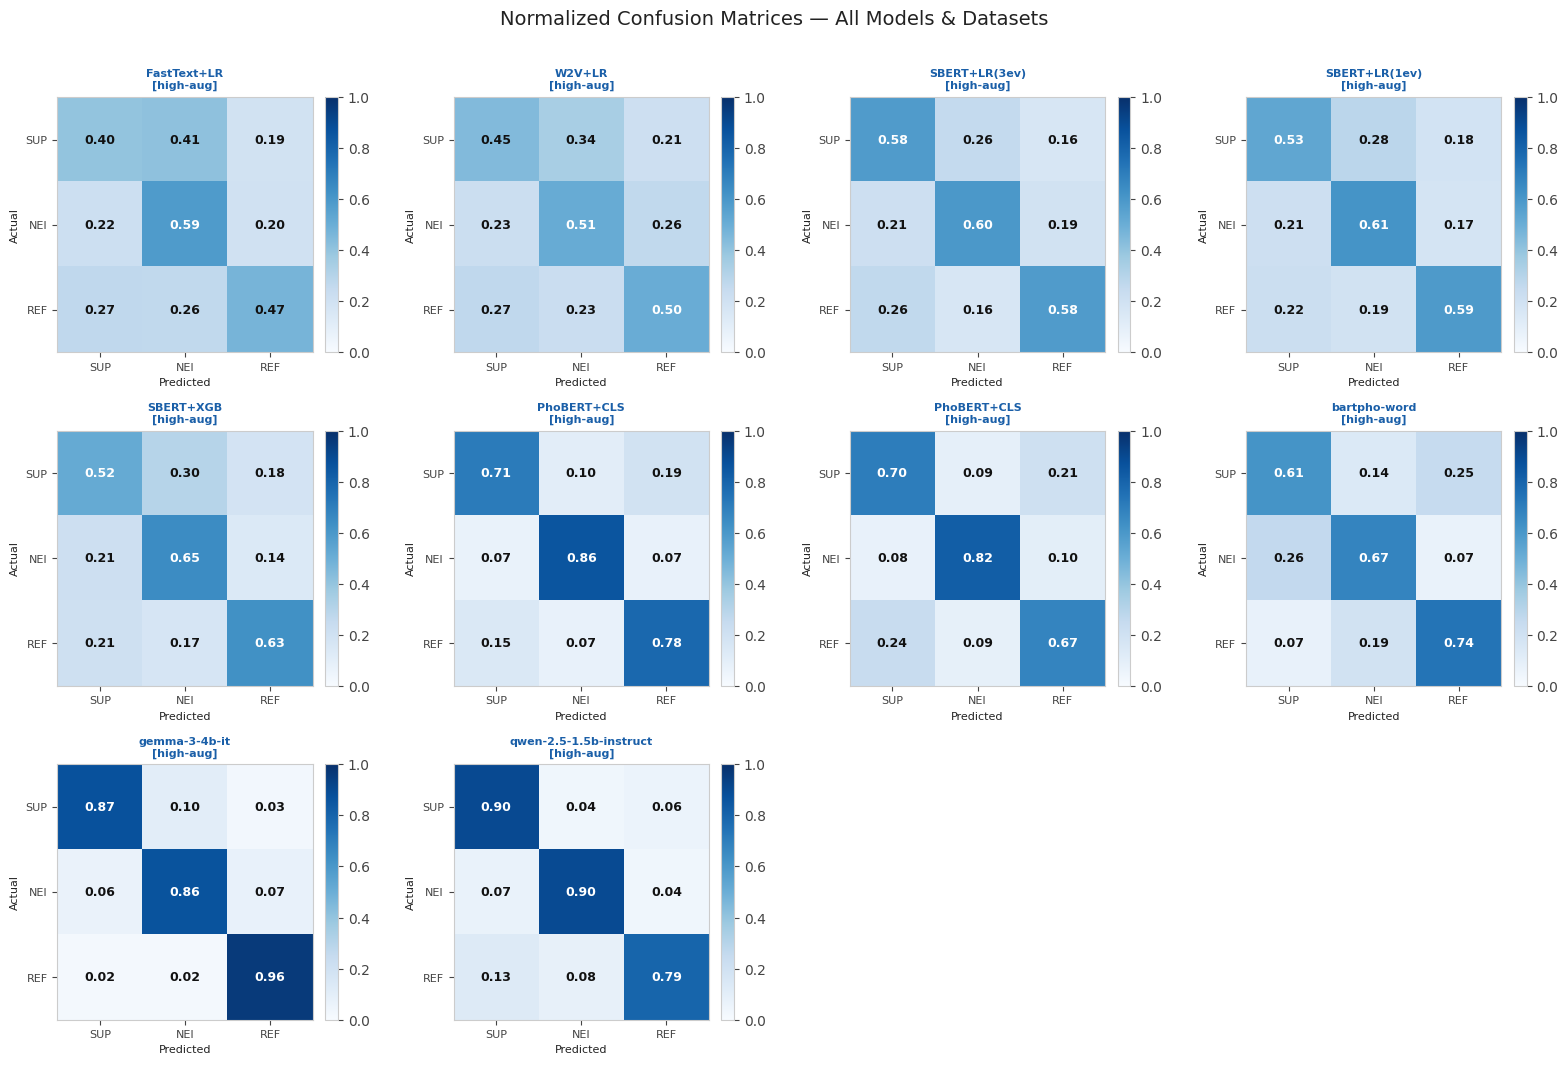

ValueError: Index contains duplicate entries, cannot reshape

In [58]:
"""
Confusion Matrix Analysis & Visualization
==========================================
Phân tích ma trận nhầm lẫn giữa các mô hình và nhãn.

Cài đặt: pip install matplotlib seaborn numpy pandas
Chạy:    python cm_analysis_light.py
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# ─────────────────────────────────────────────
# DỮ LIỆU GỐC
# ─────────────────────────────────────────────

LABELS = ['SUPPORTED', 'NEI', 'REFUTED']


# ─────────────────────────────────────────────
# HELPER FUNCTIONS
# ─────────────────────────────────────────────
def get_metrics(entry):
    """Tính precision, recall, F1, accuracy từ confusion matrix."""
    cm = np.array(entry['cm'])
    n = cm.shape[0]
    metrics = {}
    for i, lbl in enumerate(LABELS):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        metrics[lbl] = {'precision': prec, 'recall': rec, 'f1': f1}
    metrics['accuracy'] = cm.diagonal().sum() / cm.sum()
    metrics['macro_f1'] = np.mean([metrics[l]['f1'] for l in LABELS])
    return metrics

def normalize_cm(cm):
    cm = np.array(cm, dtype=float)
    return cm / cm.sum(axis=1, keepdims=True)

def short(name):
    return SHORT_NAMES.get(name, name)

# Build dataframe
rows = []
for e in all_res:
    m = get_metrics(e)
    rows.append({
        'model': short(e['name']),
        'dataset': e['dataset'],
        'label': 'SUPPORTED', 'f1': m['SUPPORTED']['f1'],
        'precision': m['SUPPORTED']['precision'], 'recall': m['SUPPORTED']['recall'],
    })
    for lbl in LABELS:
        rows.append({
            'model': short(e['name']),
            'dataset': e['dataset'],
            'label': lbl,
            'f1': m[lbl]['f1'],
            'precision': m[lbl]['precision'],
            'recall': m[lbl]['recall'],
        })

# deduplicate
df_all = pd.DataFrame(rows).drop_duplicates()

# macro f1 summary
summary = []
for e in all_res:
    m = get_metrics(e)
    summary.append({
        'model': short(e['name']),
        'dataset': e['dataset'],
        'accuracy': m['accuracy'],
        'macro_f1': m['macro_f1'],
        **{f'f1_{l}': m[l]['f1'] for l in LABELS},
        **{f'prec_{l}': m[l]['precision'] for l in LABELS},
        **{f'rec_{l}': m[l]['recall'] for l in LABELS},
    })
df_sum = pd.DataFrame(summary)

PALETTE = {'high-aug': '#1a6fbb', 'high': '#d95f02', 'full': '#1b9e4b'}
cmap_err = LinearSegmentedColormap.from_list('err', ['#ffffff', '#fc8d59', '#d73027'])
cmap_cool = LinearSegmentedColormap.from_list('cool', ['#ffffff', '#c6dbef', '#4292c6', '#08306b'])

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': '#ffffff',
    'figure.facecolor': '#ffffff',
    'text.color': '#222222',
    'axes.labelcolor': '#222222',
    'xtick.color': '#444444',
    'ytick.color': '#444444',
    'axes.edgecolor': '#cccccc',
    'grid.color': '#dddddd',
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
})


# ═══════════════════════════════════════════════════
# FIGURE 1 — Normalized Confusion Matrices (grid)
# ═══════════════════════════════════════════════════
def plot_confusion_matrices():
    entries = all_res
    n = len(entries)
    ncols = 4
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.5))
    fig.suptitle('Normalized Confusion Matrices — All Models & Datasets',
                 fontsize=14, color='#222222', y=1.01)
    axes = axes.flatten()

    for idx, entry in enumerate(entries):
        ax = axes[idx]
        ncm = normalize_cm(entry['cm'])
        im = ax.imshow(ncm, cmap='Blues', vmin=0, vmax=1)
        ax.set_xticks(range(3)); ax.set_yticks(range(3))
        ax.set_xticklabels(['SUP', 'NEI', 'REF'], fontsize=8)
        ax.set_yticklabels(['SUP', 'NEI', 'REF'], fontsize=8)
        ax.set_xlabel('Predicted', fontsize=8)
        ax.set_ylabel('Actual', fontsize=8)
        title = f"{short(entry['name'])}\n[{entry['dataset']}]"
        ax.set_title(title, fontsize=8, color='#1a5fa8')
        for i in range(3):
            for j in range(3):
                val = ncm[i, j]
                color = '#111111' if val < 0.5 else 'white'
                ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    for ax in axes[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.savefig('fig1_confusion_matrices.png', dpi=150, bbox_inches='tight',
                facecolor='#ffffff')
    print("✅  Saved: fig1_confusion_matrices.png")
    plt.show()


# ═══════════════════════════════════════════════════
# FIGURE 2 — Error Heatmap: off-diagonal confusion
# ═══════════════════════════════════════════════════
def plot_error_heatmap():
    """
    Heatmap tỷ lệ nhầm lẫn giữa từng cặp nhãn, trên mỗi mô hình×dataset.
    Rows = (model, dataset), Cols = confusion pair (Actual→Predicted).
    """
    pairs = [('SUPPORTED→NEI', 0, 1), ('SUPPORTED→REFUTED', 0, 2),
             ('NEI→SUPPORTED', 1, 0), ('NEI→REFUTED', 1, 2),
             ('REFUTED→SUPPORTED', 2, 0), ('REFUTED→NEI', 2, 1)]

    rows_h, cols_h, vals = [], [], []
    for e in all_res:
        ncm = normalize_cm(e['cm'])
        row_lbl = f"{short(e['name'])} [{e['dataset']}]"
        for col_lbl, i, j in pairs:
            rows_h.append(row_lbl)
            cols_h.append(col_lbl)
            vals.append(ncm[i, j])

    heat_df = pd.DataFrame({'row': rows_h, 'col': cols_h, 'val': vals})
    pivot = heat_df.pivot(index='row', columns='col', values='val')
    pivot = pivot[[p[0] for p in pairs]]  # reorder cols

    fig, ax = plt.subplots(figsize=(13, len(all_res) * 0.55 + 2))
    sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
                linewidths=0.4, linecolor='#eeeeee',
                cbar_kws={'label': 'Error rate (row-normalized)'})
    ax.set_title('Label Confusion Error Heatmap — tỷ lệ nhầm nhãn (actual → predicted)',
                 fontsize=12, pad=12, color='#222222')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=30, labelsize=9)
    ax.tick_params(axis='y', labelsize=8)
    plt.tight_layout()
    plt.savefig('fig2_error_heatmap.png', dpi=150, bbox_inches='tight',
                facecolor='#ffffff')
    print("✅  Saved: fig2_error_heatmap.png")
    plt.show()


# ═══════════════════════════════════════════════════
# FIGURE 3 — F1 per label, grouped bar by dataset
# ═══════════════════════════════════════════════════
def plot_f1_per_label():
    models = df_sum['model'].unique()
    datasets = ['high-aug', 'high', 'full']
    x = np.arange(len(models))
    width = 0.25

    fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
    fig.suptitle('F1-score theo từng nhãn — so sánh giữa các mô hình & dataset',
                 fontsize=13, color='#222222')

    for col_idx, lbl in enumerate(LABELS):
        ax = axes[col_idx]
        col = f'f1_{lbl}'
        for i, ds in enumerate(datasets):
            sub = df_sum[df_sum['dataset'] == ds].set_index('model')
            vals = [sub.loc[m, col] if m in sub.index else 0 for m in models]
            bars = ax.bar(x + i * width, vals, width,
                          label=ds, color=PALETTE[ds], alpha=0.85, edgecolor='#ffffff')
        ax.set_title(f'F1 — {lbl}', fontsize=11, color='#1a5fa8')
        ax.set_xticks(x + width)
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=7.5)
        ax.set_ylim(0, 1)
        ax.yaxis.grid(True, linestyle='--', alpha=0.5)
        ax.legend(fontsize=8) if col_idx == 0 else None

    plt.tight_layout()
    plt.savefig('fig3_f1_per_label.png', dpi=150, bbox_inches='tight',
                facecolor='#ffffff')
    print("✅  Saved: fig3_f1_per_label.png")
    plt.show()


# ═══════════════════════════════════════════════════
# FIGURE 4 — Precision vs Recall scatter per label
# ═══════════════════════════════════════════════════
def plot_prec_recall_scatter():
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Precision vs Recall theo từng nhãn — mỗi điểm là 1 mô hình×dataset',
                 fontsize=13, color='#222222')
    markers = {'high-aug': 'o', 'high': '^', 'full': 's'}
    colors_m = {n: plt.cm.Set2(i / len(df_sum['model'].unique()))
                for i, n in enumerate(df_sum['model'].unique())}

    for col_idx, lbl in enumerate(LABELS):
        ax = axes[col_idx]
        col_p = f'prec_{lbl}'; col_r = f'rec_{lbl}'
        for _, row in df_sum.iterrows():
            ax.scatter(row[col_r], row[col_p],
                       marker=markers[row['dataset']],
                       color=colors_m[row['model']],
                       s=90, edgecolors='#444444', linewidth=0.5,
                       label=f"{row['model']} [{row['dataset']}]",
                       zorder=3)
        # F1 iso-curves
        for f1_target in [0.4, 0.5, 0.6, 0.7]:
            r_vals = np.linspace(0.01, 1, 200)
            p_vals = f1_target * r_vals / (2 * r_vals - f1_target)
            mask = (p_vals > 0) & (p_vals <= 1)
            ax.plot(r_vals[mask], p_vals[mask], '--', color='#aaaaaa',
                    linewidth=0.8, alpha=0.7)
            idx_mid = np.argmin(np.abs(r_vals[mask] - 0.85))
            ax.text(r_vals[mask][idx_mid], p_vals[mask][idx_mid],
                    f'F1={f1_target}', fontsize=6, color='#888888')

        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_xlabel('Recall', fontsize=9)
        ax.set_ylabel('Precision', fontsize=9)
        ax.set_title(f'{lbl}', fontsize=11, color='#1a5fa8')
        ax.plot([0, 1], [0, 1], ':', color='#aaaaaa', linewidth=0.8)
        ax.grid(True, linestyle='--', alpha=0.4)

    # one legend outside
    handles = [plt.Line2D([0], [0], marker=m, color='#555555',
               linestyle='None', markersize=7, label=ds)
               for ds, m in markers.items()]
    fig.legend(handles=handles, title='Dataset', loc='lower center',
               ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout()
    plt.savefig('fig4_prec_recall.png', dpi=150, bbox_inches='tight',
                facecolor='#ffffff')
    print("✅  Saved: fig4_prec_recall.png")
    plt.show()


# ═══════════════════════════════════════════════════
# FIGURE 5 — Macro-F1 ranking & accuracy overview
# ═══════════════════════════════════════════════════
def plot_ranking():
    fig, axes = plt.subplots(1, 2, figsize=(16, 10))
    fig.suptitle('Xếp hạng mô hình — Macro-F1 & Accuracy', fontsize=13, color='#222222')

    for ax, metric, label in zip(axes, ['macro_f1', 'accuracy'],
                                 ['Macro F1', 'Accuracy']):
        sub = df_sum.sort_values(metric, ascending=True)
        bar_labels = [f"{r['model']}\n[{r['dataset']}]" for _, r in sub.iterrows()]
        colors = [PALETTE[r['dataset']] for _, r in sub.iterrows()]
        bars = ax.barh(bar_labels, sub[metric], color=colors, edgecolor='#ffffff', height=0.7)
        for bar, val in zip(bars, sub[metric]):
            ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                    f'{val:.3f}', va='center', fontsize=8, color='#333333')
        ax.set_xlim(0, 1)
        ax.set_title(label, fontsize=11, color='#1a5fa8')
        ax.xaxis.grid(True, linestyle='--', alpha=0.5)
        ax.set_xlabel(label, fontsize=9)
        ax.tick_params(axis='y', labelsize=7)

    legend_handles = [Patch(color=c, label=ds) for ds, c in PALETTE.items()]
    fig.legend(handles=legend_handles, title='Dataset', loc='lower center',
               ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.04))
    plt.tight_layout()
    plt.savefig('fig5_ranking.png', dpi=150, bbox_inches='tight',
                facecolor='#ffffff')
    print("✅  Saved: fig5_ranking.png")
    plt.show()


# ═══════════════════════════════════════════════════
# FIGURE 6 — Dataset effect: high-aug vs high vs full
#            (paired delta F1, chỉ mô hình có ≥2 dataset)
# ═══════════════════════════════════════════════════
def plot_dataset_effect():
    """
    So sánh macro-F1 của cùng một mô hình trên các dataset khác nhau.
    Cho thấy data augmentation hoặc filtering có ảnh hưởng thế nào.
    """
    pivot = df_sum.pivot_table(index='model', columns='dataset', values='macro_f1')
    pivot = pivot.dropna(thresh=2)   # chỉ model có ít nhất 2 dataset

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(pivot))
    width = 0.25
    ds_list = [c for c in ['high-aug', 'high', 'full'] if c in pivot.columns]
    for i, ds in enumerate(ds_list):
        if ds in pivot.columns:
            ax.bar(x + i * width, pivot[ds].fillna(0), width,
                   label=ds, color=PALETTE[ds], alpha=0.85, edgecolor='#ffffff')

    ax.set_xticks(x + width)
    ax.set_xticklabels(pivot.index, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Macro F1', fontsize=10)
    ax.set_title('Ảnh hưởng của Dataset lên Macro-F1 (cùng mô hình)',
                 fontsize=12, color='#222222')
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.legend(title='Dataset', fontsize=9)
    plt.tight_layout()
    plt.savefig('fig6_dataset_effect.png', dpi=150, bbox_inches='tight',
                facecolor='#ffffff')
    print("✅  Saved: fig6_dataset_effect.png")
    plt.show()


# ═══════════════════════════════════════════════════
# FIGURE 7 — REFUTED bias analysis
#            Mô hình nào thường nhầm REFUTED → nhãn khác?
# ═══════════════════════════════════════════════════
def plot_refuted_bias():
    """
    REFUTED thường khó nhất. Phân tích tỷ lệ nhầm REFUTED→SUP và REFUTED→NEI.
    """
    records = []
    for e in all_res:
        ncm = normalize_cm(e['cm'])
        records.append({
            'label': f"{short(e['name'])}\n[{e['dataset']}]",
            'REFUTED→SUP': ncm[2, 0],
            'REFUTED→NEI': ncm[2, 1],
            'REFUTED correct': ncm[2, 2],
        })
    rdf = pd.DataFrame(records).sort_values('REFUTED correct', ascending=True)

    x = np.arange(len(rdf))
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(x, rdf['REFUTED correct'], color='#1b9e4b', label='Correct (REFUTED)', alpha=0.9)
    ax.barh(x, rdf['REFUTED→NEI'], left=rdf['REFUTED correct'],
            color='#d95f02', label='Confused → NEI', alpha=0.85)
    ax.barh(x, rdf['REFUTED→SUP'], left=rdf['REFUTED correct'] + rdf['REFUTED→NEI'],
            color='#d7191c', label='Confused → SUPPORTED', alpha=0.85)

    ax.set_yticks(x)
    ax.set_yticklabels(rdf['label'], fontsize=7.5)
    ax.set_xlabel('Tỷ lệ (row-normalized)', fontsize=10)
    ax.set_title('Phân tích nhầm lẫn nhãn REFUTED — mô hình nào bị bias nhất?',
                 fontsize=12, color='#222222')
    ax.legend(fontsize=9, loc='lower right')
    ax.xaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.savefig('fig7_refuted_bias.png', dpi=150, bbox_inches='tight',
                facecolor='#ffffff')
    print("✅  Saved: fig7_refuted_bias.png")
    plt.show()


# ═══════════════════════════════════════════════════
# MAIN
# ═══════════════════════════════════════════════════
if __name__ == '__main__':
    print("=" * 60)
    print("  Confusion Matrix Analysis — Vietnamese Fact Verification")
    print("=" * 60)

    print("\n📊 Macro-F1 Summary (top 5):")
    top5 = df_sum.sort_values('macro_f1', ascending=False).head(5)
    print(top5[['model', 'dataset', 'macro_f1', 'accuracy']].to_string(index=False))

    print("\n🔍 Mô hình nhầm REFUTED nhiều nhất:")
    worst_ref = []
    for e in all_res:
        ncm = normalize_cm(e['cm'])
        worst_ref.append((short(e['name']), e['dataset'], 1 - ncm[2, 2]))
    worst_ref.sort(key=lambda x: -x[2])
    for nm, ds, err in worst_ref[:5]:
        print(f"  {nm} [{ds}]  — REFUTED error rate: {err:.2%}")

    print("\n🎨 Đang vẽ các biểu đồ... (7 figures)\n")
    plot_confusion_matrices()   # Fig 1
    plot_error_heatmap()        # Fig 2
    plot_f1_per_label()         # Fig 3
    plot_prec_recall_scatter()  # Fig 4
    plot_ranking()              # Fig 5
    # plot_dataset_effect()       # Fig 6
    plot_refuted_bias()         # Fig 7

    print("\n✅  Hoàn tất! Tất cả ảnh đã được lưu vào thư mục hiện tại.")

✅ Đã lưu: insight3_avg_f1_3_labels.png


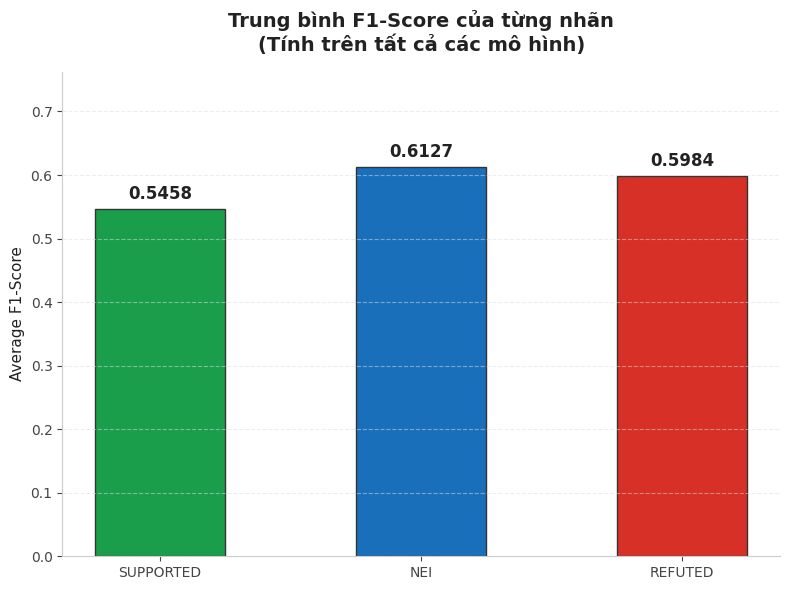

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_average_f1_per_label(all_res):
    """
    Tính và vẽ biểu đồ F1-score trung bình của từng nhãn 
    (tính trung bình trên tất cả các mô hình và dataset hiện có).
    """
    # Khởi tạo danh sách lưu F1 của từng nhãn
    f1_scores = {
        'SUPPORTED': [],
        'NEI': [],
        'REFUTED': []
    }
    
    # Lấy dữ liệu từ all_res
    for e in all_res:
        m = get_metrics(e)
        for lbl in f1_scores.keys():
            f1_scores[lbl].append(m[lbl]['f1'])
            
    # Tính trung bình (mean) cho mỗi nhãn
    avg_f1 = {
        'SUPPORTED': np.mean(f1_scores['SUPPORTED']),
        'NEI': np.mean(f1_scores['NEI']),
        'REFUTED': np.mean(f1_scores['REFUTED'])
    }
    
    # Chuẩn bị dữ liệu vẽ
    labels = list(avg_f1.keys())
    values = list(avg_f1.values())
    
    # Sử dụng màu sắc nhất quán với các hàm trước
    colors = ['#1b9e4b', '#1a6fbb', '#d73027']  # Xanh lá (SUP), Xanh dương (NEI), Đỏ (REF)
    
    # Vẽ biểu đồ
    plt.figure(figsize=(8, 6))
    bars = plt.bar(labels, values, color=colors, width=0.5, edgecolor='#333333')
    
    # Hiển thị số liệu trực tiếp trên đỉnh mỗi cột
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.01, 
                 f'{yval:.4f}', 
                 ha='center', va='bottom', 
                 fontweight='bold', fontsize=12, color='#222222')
                 
    # Tùy chỉnh biểu đồ
    plt.title('Trung bình F1-Score của từng nhãn\n(Tính trên tất cả các mô hình)', 
              fontsize=14, fontweight='bold', color='#222222', pad=15)
    plt.ylabel('Average F1-Score', fontsize=11)
    
    # Tăng limit trục y thêm một chút để không bị lẹm chữ
    plt.ylim(0, max(values) + 0.15)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Xóa viền trên và viền phải cho biểu đồ thanh thoát hơn
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    plt.savefig('insight3_avg_f1_3_labels.png', dpi=150, facecolor='#ffffff')
    print("✅ Đã lưu: insight3_avg_f1_3_labels.png")
    plt.show()

# --- CÁCH CHẠY ---
plot_average_f1_per_label(all_res)


 BẢNG XẾP HẠNG ASYMMETRIC RISK SCORE (α=1, β=1)
 Ghi chú: Điểm càng THẤP càng an toàn.
                   Model P(REF->SUP) P(SUP->REF)  Risk_Score
  PhoBERT+CLS [high-aug]      14.68%      18.87%      0.3355
    SBERT+XGB [high-aug]      20.63%      18.35%      0.3899
SBERT+LR(1ev) [high-aug]      22.22%      18.49%      0.4071
SBERT+LR(3ev) [high-aug]      26.19%      16.23%      0.4242
  FastText+LR [high-aug]      26.59%      18.87%      0.4546
       W2V+LR [high-aug]      26.59%      21.13%      0.4772

✅ Đã lưu biểu đồ: insight4_asymmetric_risk.png


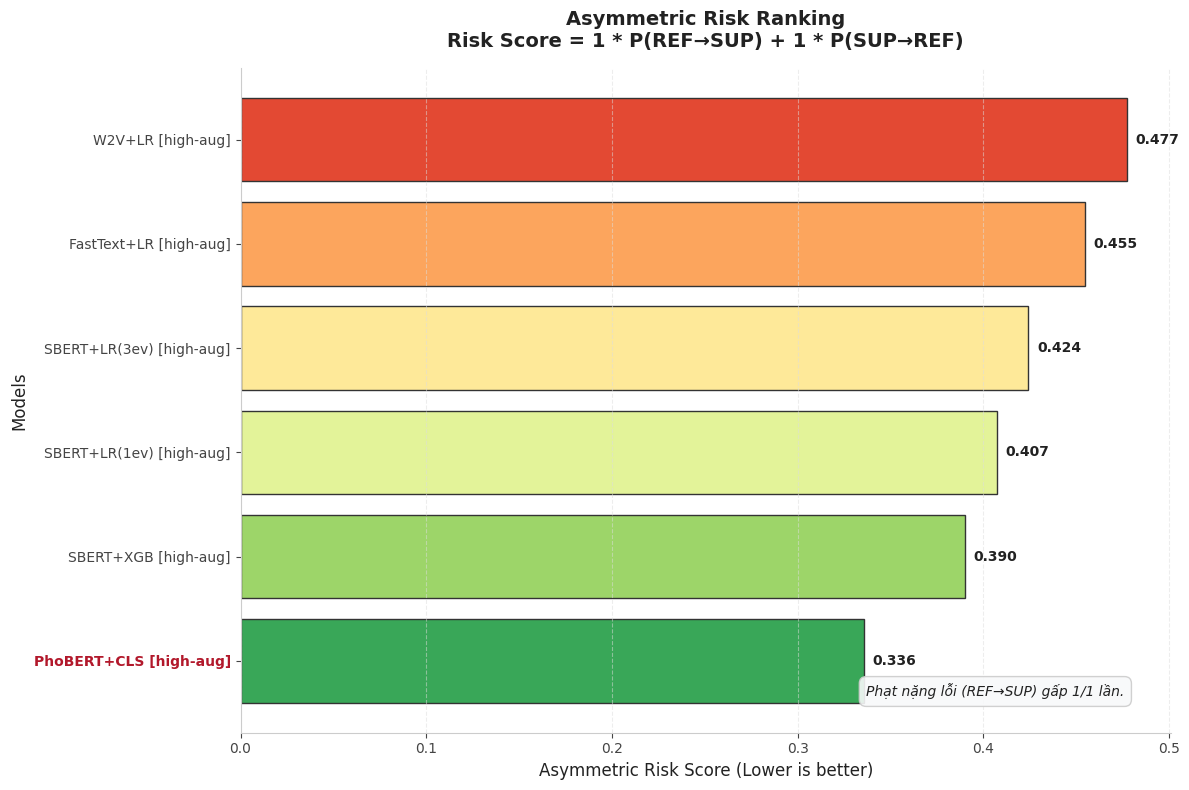

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calculate_and_plot_risk_score(all_res, alpha=3, beta=1):
    """
    Tính toán và trực quan hóa Asymmetric Risk Score.
    RiskScore = alpha * P(REF->SUP) + beta * P(SUP->REF)
    """
    records = []
    
    for e in all_res:
        # Lấy ma trận nhầm lẫn đã chuẩn hóa (chuyển về xác suất theo hàng)
        ncm = normalize_cm(e['cm'])
        model_name = f"{short(e['name'])} [{e['dataset']}]"
        
        # P(REF -> SUP): Thực tế REFUTED (row 2), đoán SUPPORTED (col 0)
        p_ref_sup = ncm[2, 0]
        
        # P(SUP -> REF): Thực tế SUPPORTED (row 0), đoán REFUTED (col 2)
        p_sup_ref = ncm[0, 2]
        
        # Tính Risk Score theo công thức
        risk_score = (alpha * p_ref_sup) + (beta * p_sup_ref)
        
        records.append({
            'Model': model_name,
            'P(REF->SUP)': p_ref_sup,
            'P(SUP->REF)': p_sup_ref,
            'Risk_Score': risk_score
        })
        
    df_risk = pd.DataFrame(records)
    
    # Sắp xếp từ rủi ro THẤP NHẤT (tốt nhất) lên CAO NHẤT (kém nhất)
    df_risk = df_risk.sort_values('Risk_Score', ascending=True)
    
    # ---------------------------------------------------------
    # 1. IN BẢNG RA CONSOLE CHO BÀI BÁO
    # ---------------------------------------------------------
    print("\n" + "="*80)
    print(f" BẢNG XẾP HẠNG ASYMMETRIC RISK SCORE (α={alpha}, β={beta})")
    print(" Ghi chú: Điểm càng THẤP càng an toàn.")
    print("="*80)
    
    # Format lại để in ra cho đẹp
    df_print = df_risk.copy()
    df_print['P(REF->SUP)'] = (df_print['P(REF->SUP)'] * 100).round(2).astype(str) + '%'
    df_print['P(SUP->REF)'] = (df_print['P(SUP->REF)'] * 100).round(2).astype(str) + '%'
    df_print['Risk_Score'] = df_print['Risk_Score'].round(4)
    print(df_print.to_string(index=False))
    
    # ---------------------------------------------------------
    # 2. VẼ BIỂU ĐỒ RANKING
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 8))
    
    # Tạo dải màu: Mô hình rủi ro thấp có màu xanh, rủi ro cao có màu đỏ/cam
    # "RdYlGn_r" là dải màu Đỏ-Vàng-Xanh bị đảo ngược (reversed)
    colors = sns.color_palette("RdYlGn_r", len(df_risk))
    
    bars = plt.barh(df_risk['Model'], df_risk['Risk_Score'], color=colors, edgecolor='#333333')
    
    # Thêm text giá trị trực tiếp lên đỉnh cột
    for bar, val in zip(bars, df_risk['Risk_Score']):
        offset = max(df_risk['Risk_Score']) * 0.01
        plt.text(val + offset, bar.get_y() + bar.get_height()/2, 
                 f'{val:.3f}', va='center', fontsize=10, fontweight='bold', color='#222222')
                 
    # Tùy chỉnh biểu đồ
    plt.title(f'Asymmetric Risk Ranking\nRisk Score = {alpha} * P(REF→SUP) + {beta} * P(SUP→REF)', 
              fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Asymmetric Risk Score (Lower is better)', fontsize=12)
    plt.ylabel('Models', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    ax = plt.gca()
    for label in ax.get_yticklabels():
        if 'PhoBERT' in label.get_text():
            label.set_fontweight('bold')
            label.set_color('#b2182b') # Màu đỏ đô cho đẹp
    
    # Thêm textbox giải thích vào góc dưới phải
    box_text = f"Phạt nặng lỗi (REF→SUP) gấp {alpha}/{beta} lần."
    plt.text(0.95, 0.05, box_text, 
             transform=plt.gca().transAxes, ha='right', va='bottom', 
             fontsize=10, style='italic',
             bbox=dict(facecolor='#f8f9fa', alpha=0.9, edgecolor='#cccccc', boxstyle='round,pad=0.5'))

    # Loại bỏ viền trên và phải
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('insight4_asymmetric_risk.png', dpi=150, facecolor='#ffffff')
    print("\n✅ Đã lưu biểu đồ: insight4_asymmetric_risk.png")
    plt.show()

# --- CÁCH CHẠY ---
# Gọi hàm với tham số hệ số phạt bạn mong muốn
calculate_and_plot_risk_score(all_res, alpha=1, beta=1)

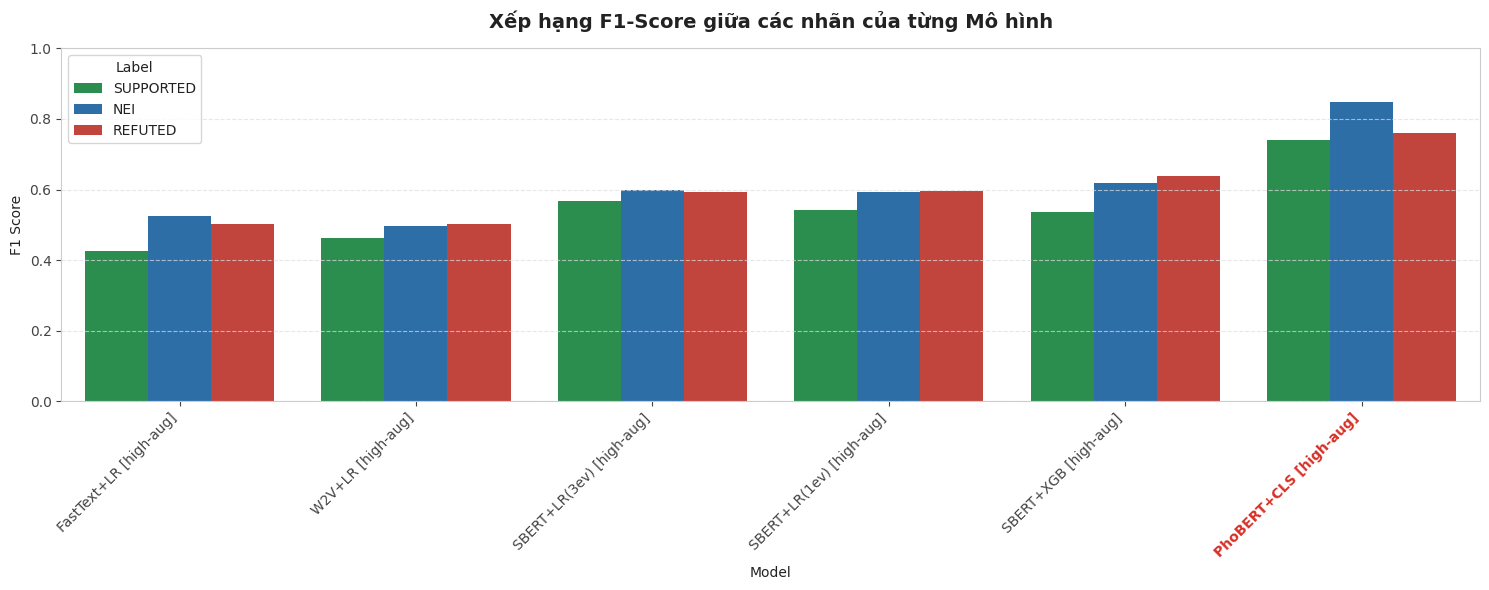

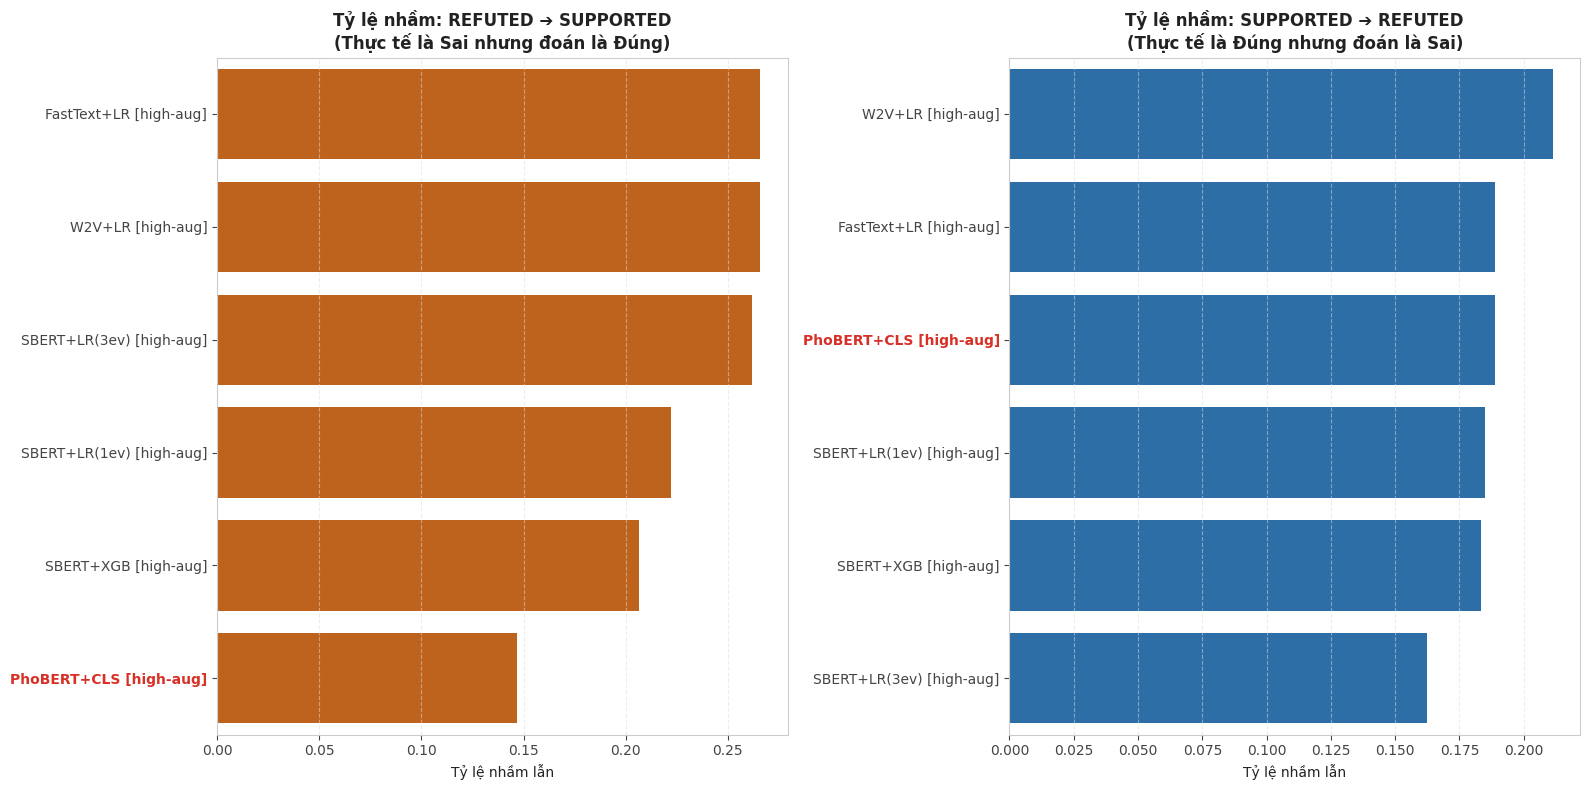

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_critical_insights(all_res):
    """
    Phân tích insight: 
    1. So sánh F1-score giữa các nhãn.
    2. Xếp hạng lỗi nhầm lẫn nghiêm trọng: REFUTED -> SUPPORTED và SUPPORTED -> REFUTED.
    """
    records = []
    
    # Trích xuất dữ liệu
    for e in all_res:
        model_name = f"{short(e['name'])} [{e['dataset']}]"
        m = get_metrics(e)
        ncm = normalize_cm(e['cm'])
        
        ref_to_sup = ncm[2, 0]
        sup_to_ref = ncm[0, 2]
        
        records.append({
            'Model': model_name,
            'F1_SUPPORTED': m['SUPPORTED']['f1'],
            'F1_NEI': m['NEI']['f1'],
            'F1_REFUTED': m['REFUTED']['f1'],
            'REFUTED_to_SUPPORTED': ref_to_sup,
            'SUPPORTED_to_REFUTED': sup_to_ref
        })

    df = pd.DataFrame(records)

    # ---------------------------------------------------------
    # BIỂU ĐỒ 1: XẾP HẠNG F1-SCORE GIỮA CÁC NHÃN
    # ---------------------------------------------------------
    df_f1 = df[['Model', 'F1_SUPPORTED', 'F1_NEI', 'F1_REFUTED']].melt(
        id_vars='Model', var_name='Label', value_name='F1 Score'
    )
    df_f1['Label'] = df_f1['Label'].str.replace('F1_', '')

    plt.figure(figsize=(15, 6))
    sns.barplot(data=df_f1, x='Model', y='F1 Score', hue='Label', 
                palette={'SUPPORTED': '#1b9e4b', 'NEI': '#1a6fbb', 'REFUTED': '#d73027'})
    plt.title('Xếp hạng F1-Score giữa các nhãn của từng Mô hình', fontsize=14, fontweight='bold', pad=15)
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # ---> TÔ ĐẬM PHOBERT TRỤC X (BIỂU ĐỒ 1) <---
    ax = plt.gca()
    for label in ax.get_xticklabels():
        if 'PhoBERT' in label.get_text():
            label.set_fontweight('bold')
            label.set_color('#d73027') # Đổi sang màu đỏ đô cho nổi bật

    plt.tight_layout()
    plt.savefig('insight1_f1_scores.png', dpi=150)
    plt.show()

    # ---------------------------------------------------------
    # BIỂU ĐỒ 2 & 3: XẾP HẠNG NHẦM LẪN NGHIÊM TRỌNG (Ngược nhau)
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    df_r2s = df.sort_values('REFUTED_to_SUPPORTED', ascending=False)
    sns.barplot(data=df_r2s, x='REFUTED_to_SUPPORTED', y='Model', ax=axes[0], color='#d95f02')
    axes[0].set_title('Tỷ lệ nhầm: REFUTED ➔ SUPPORTED\n(Thực tế là Sai nhưng đoán là Đúng)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Tỷ lệ nhầm lẫn', fontsize=10)
    axes[0].set_ylabel('')
    axes[0].grid(axis='x', linestyle='--', alpha=0.5)

    df_s2r = df.sort_values('SUPPORTED_to_REFUTED', ascending=False)
    sns.barplot(data=df_s2r, x='SUPPORTED_to_REFUTED', y='Model', ax=axes[1], color='#1a6fbb')
    axes[1].set_title('Tỷ lệ nhầm: SUPPORTED ➔ REFUTED\n(Thực tế là Đúng nhưng đoán là Sai)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Tỷ lệ nhầm lẫn', fontsize=10)
    axes[1].set_ylabel('')
    axes[1].grid(axis='x', linestyle='--', alpha=0.5)

    # ---> TÔ ĐẬM PHOBERT TRỤC Y (BIỂU ĐỒ 2 & 3) <---
    for ax in axes:
        for label in ax.get_yticklabels():
            if 'PhoBERT' in label.get_text():
                label.set_fontweight('bold')
                label.set_color('#d73027')

    plt.tight_layout()
    plt.savefig('insight2_critical_confusions.png', dpi=150)
    plt.show()

    # # ---------------------------------------------------------
    # # IN BẢNG XẾP HẠNG RA CONSOLE
    # # ---------------------------------------------------------
    # # ---> HÀM PHỤ TRỢ TÔ ĐẬM CONSOLE <---
    # def bold_if_phobert(val):
    #     if isinstance(val, str) and 'PhoBERT' in val:
    #         return f"\033[1m{val}\033[0m"
    #     return val

    # print("\n" + "="*60)
    # print(" BẢNG XẾP HẠNG: REFUTED ➔ SUPPORTED (Tồi tệ nhất lên đầu)")
    # print("="*60)
    # df_r2s_print = df_r2s[['Model', 'REFUTED_to_SUPPORTED']].copy()
    # df_r2s_print['REFUTED_to_SUPPORTED'] = (df_r2s_print['REFUTED_to_SUPPORTED'] * 100).round(2).astype(str) + '%'
    # df_r2s_print['Model'] = df_r2s_print['Model'].apply(bold_if_phobert) # Áp dụng tô đậm
    # print(df_r2s_print.to_string(index=False))

    # print("\n" + "="*60)
    # print(" BẢNG XẾP HẠNG: SUPPORTED ➔ REFUTED (Tồi tệ nhất lên đầu)")
    # print("="*60)
    # df_s2r_print = df_s2r[['Model', 'SUPPORTED_to_REFUTED']].copy()
    # df_s2r_print['SUPPORTED_to_REFUTED'] = (df_s2r_print['SUPPORTED_to_REFUTED'] * 100).round(2).astype(str) + '%'
    # df_s2r_print['Model'] = df_s2r_print['Model'].apply(bold_if_phobert) # Áp dụng tô đậm
    # print(df_s2r_print.to_string(index=False))
    
    # print("\n✅ Đã lưu: insight1_f1_scores.png và insight2_critical_confusions.png")

# -- CÁCH CHẠY --
plot_critical_insights(all_res)

# Kết quả theo từng nhóm phương pháp

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các nhóm phương pháp chuẩn

def normalize_cm(cm):
    cm = np.array(cm, dtype=float)
    return cm / cm.sum(axis=1, keepdims=True)
MAIN_METHODS = ['ml', 'encoder', 'seq2seq', 'api-llm', 'decoder']

def calc_f1(precision, recall):
    """Hàm phụ trợ tính F1-score từ Precision và Recall"""
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)

def plot_method_insights(all_res):
    """
    Phân tích insight theo từng NHÓM PHƯƠNG PHÁP:
    1. So sánh Macro F1 giữa các nhóm phương pháp.
    2. So sánh F1-score của từng nhãn theo nhóm.
    3. Xếp hạng lỗi nhầm lẫn nghiêm trọng (nếu input có chứa 'cm').
    """
    records = []
    
    # ---------------------------------------------------------
    # 1. TRÍCH XUẤT VÀ TÍNH TOÁN DỮ LIỆU
    # ---------------------------------------------------------
    for e in all_res:
        method = e.get('method', 'unknown')
        print(method)
        if method not in MAIN_METHODS:
            method = 'other'
            
        model_name = f"{e.get('name', 'Unknown')} [{e.get('dataset', 'unknown')}]"
        
        # Tính F1 cho từng nhãn từ [precision, recall]
        f1_sup = calc_f1(e['SUPPORTED'][0], e['SUPPORTED'][1])
        f1_nei = calc_f1(e['NEI'][0], e['NEI'][1])
        f1_ref = calc_f1(e['REFUTED'][0], e['REFUTED'][1])
        
        record = {
            'Method': method,
            'Model': model_name,
            'Macro_F1': e.get('f1', 0.0),
            'F1_SUPPORTED': f1_sup,
            'F1_NEI': f1_nei,
            'F1_REFUTED': f1_ref
        }
        
        # Nếu input của bạn vẫn truyền vào 'cm', ta tính lỗi nghiêm trọng
        if 'cm' in e:
            ncm = normalize_cm(e['cm']) # Cần đảm bảo hàm normalize_cm đã được định nghĩa
            record['REFUTED_to_SUPPORTED'] = ncm[2, 0]
            record['SUPPORTED_to_REFUTED'] = ncm[0, 2]
            
        records.append(record)

    df = pd.DataFrame(records)

    # ---------------------------------------------------------
    # BIỂU ĐỒ 1: PHÂN BỐ MACRO F1 THEO TỪNG NHÓM PHƯƠNG PHÁP
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    
    # Dùng barplot để lấy giá trị trung bình của từng nhóm
    sns.barplot(data=df, x='Method', y='Macro_F1', 
                order=MAIN_METHODS, palette='Set2', errorbar='sd', capsize=0.1)
    # Vẽ đè các điểm dữ liệu cụ thể (từng model) để thấy rõ phân bố
    sns.stripplot(data=df, x='Method', y='Macro_F1', 
                  order=MAIN_METHODS, color='black', alpha=0.6, jitter=True)
                  
    plt.title('Hiệu suất Macro-F1 trung bình theo Nhóm Phương Pháp', fontsize=14, fontweight='bold', pad=15)
    plt.ylabel('Test-Macro F1')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('insight1_macro_f1_by_method.png', dpi=150)
    plt.show()

    # ---------------------------------------------------------
    # BIỂU ĐỒ 2: F1-SCORE TRUNG BÌNH CỦA CÁC NHÃN THEO NHÓM
    # ---------------------------------------------------------
    # Chuyển đổi dataframe để vẽ biểu đồ nhóm
    df_f1 = df[['Method', 'F1_SUPPORTED', 'F1_NEI', 'F1_REFUTED']].melt(
        id_vars='Method', var_name='Label', value_name='F1 Score'
    )
    df_f1['Label'] = df_f1['Label'].str.replace('F1_', '')

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_f1, x='Method', y='F1 Score', hue='Label', order=MAIN_METHODS,
                palette={'SUPPORTED': '#1b9e4b', 'NEI': '#1a6fbb', 'REFUTED': '#d73027'},
                errorbar=None) # Không hiển thị sai số để biểu đồ gọn gàng
    plt.title('F1-Score trung bình của từng Nhãn theo Nhóm Phương Pháp', fontsize=14, fontweight='bold', pad=15)
    plt.ylim(0, 1.0)
    plt.legend(title='Nhãn', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig('insight2_f1_labels_by_method.png', dpi=150)
    plt.show()

    # ---------------------------------------------------------
    # IN BẢNG THỐNG KÊ RA CONSOLE
    # ---------------------------------------------------------
    print("\n" + "="*70)
    print(" BẢNG THỐNG KÊ TRUNG BÌNH THEO NHÓM PHƯƠNG PHÁP")
    print("="*70)
    
    # Tính trung bình các chỉ số theo nhóm phương pháp
    df_summary = df.groupby('Method')[['Macro_F1', 'F1_SUPPORTED', 'F1_NEI', 'F1_REFUTED']].mean().reset_index()
    
    # Định dạng %
    for col in ['Macro_F1', 'F1_SUPPORTED', 'F1_NEI', 'F1_REFUTED']:
        df_summary[col] = (df_summary[col] * 100).round(2).astype(str) + '%'
        
    print(df_summary.to_string(index=False))

    # ---------------------------------------------------------
    # BIỂU ĐỒ 3 (TÙY CHỌN): LỖI NHẦM LẪN NGHIÊM TRỌNG (Nếu có 'cm')
    # ---------------------------------------------------------
    if 'REFUTED_to_SUPPORTED' in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        # Tính trung bình lỗi theo phương pháp
        df_err = df.groupby('Method')[['REFUTED_to_SUPPORTED', 'SUPPORTED_to_REFUTED']].mean().reset_index()

        sns.barplot(data=df_err.sort_values('REFUTED_to_SUPPORTED', ascending=False), 
                    x='REFUTED_to_SUPPORTED', y='Method', ax=axes[0], color='#d95f02')
        axes[0].set_title('Tỷ lệ nhầm trung bình: REFUTED ➔ SUPPORTED', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Tỷ lệ nhầm lẫn trung bình', fontsize=10)
        axes[0].grid(axis='x', linestyle='--', alpha=0.5)

        sns.barplot(data=df_err.sort_values('SUPPORTED_to_REFUTED', ascending=False), 
                    x='SUPPORTED_to_REFUTED', y='Method', ax=axes[1], color='#1a6fbb')
        axes[1].set_title('Tỷ lệ nhầm trung bình: SUPPORTED ➔ REFUTED', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Tỷ lệ nhầm lẫn trung bình', fontsize=10)
        axes[1].grid(axis='x', linestyle='--', alpha=0.5)

        plt.tight_layout()
        plt.savefig('insight3_critical_confusions_by_method.png', dpi=150)
        plt.show()
        print("\n✅ Đã lưu: insight3_critical_confusions_by_method.png")

    print("\n✅ Đã lưu: insight1_macro_f1_by_method.png và insight2_f1_labels_by_method.png")

# -- CÁCH CHẠY --
# Truyền biến all_res của bạn vào hàm thay cho ml_res
plot_method_insights(all_res)

ml
ml
ml
ml
ml
encoder
encoder
seq2seq
decoder
decoder


IndexError: list index out of range

ml
ml
ml
ml
ml
encoder
encoder
seq2seq
decoder
decoder

 BẢNG XẾP HẠNG ASYMMETRIC RISK SCORE THEO NHÓM PHƯƠNG PHÁP (α=2, β=1)
 Ghi chú: Điểm càng THẤP càng an toàn (ít rủi ro thông tin).
              Method P(REF->SUP) P(SUP->REF)  Risk_Score
             decoder       7.43%       4.39%      0.1925
             seq2seq       7.43%      24.65%      0.3950
encoder      19.34%      19.92%      0.5860
                  ml      24.44%      18.61%      0.6750

✅ Đã lưu biểu đồ nhóm: insight4_asymmetric_risk_grouped.png


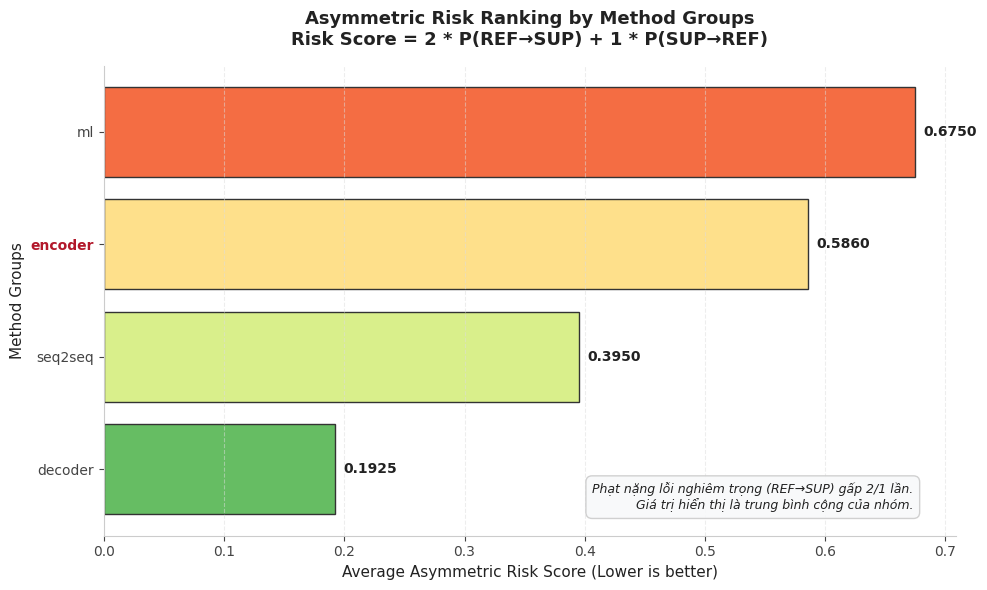

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

MAIN_METHODS = ['ml', 'encoder', 'seq2seq', 'api-llm', 'decoder']

def calculate_and_plot_grouped_risk_score(all_res, alpha=3, beta=1):
    """
    Tính toán và trực quan hóa Asymmetric Risk Score theo TỪNG NHÓM PHƯƠNG PHÁP.
    RiskScore = alpha * P(REF->SUP) + beta * P(SUP->REF)
    """
    records = []
    
    for e in all_res:
        method = e.get('method', 'unknown')
        print(method)
        if method not in MAIN_METHODS:
            method = 'other'
            
        # Kiểm tra ma trận nhầm lẫn 'cm' để tránh lỗi crash nếu thiếu dữ liệu
        if 'cm' in e:
            ncm = normalize_cm(e['cm']) # Đảm bảo hàm normalize_cm đã được định nghĩa
            p_ref_sup = ncm[2, 0] # Thực tế REFUTED, đoán SUPPORTED
            p_sup_ref = ncm[0, 2] # Thực tế SUPPORTED, đoán REFUTED
        else:
            p_ref_sup = 0.0
            p_sup_ref = 0.0
        
        # Tính Risk Score tạm thời cho từng model trước khi gom nhóm
        risk_score = (alpha * p_ref_sup) + (beta * p_sup_ref)
        
        records.append({
            'Method': method,
            'P(REF->SUP)': p_ref_sup,
            'P(SUP->REF)': p_sup_ref,
            'Risk_Score': risk_score
        })
        
    df = pd.DataFrame(records)
    
    # ---------------------------------------------------------
    # GOM NHÓM THEO PHƯƠNG PHÁP (Tính trung bình cộng chỉ số rủi ro)
    # ---------------------------------------------------------
    df_grouped = df.groupby('Method', as_index=False).mean()
    
    # Sắp xếp từ rủi ro THẤP NHẤT (tốt nhất) lên CAO NHẤT (kém nhất)
    df_grouped = df_grouped.sort_values('Risk_Score', ascending=True)
    
    # ---------------------------------------------------------
    # 1. IN BẢNG RA CONSOLE CHO BÀI BÁO (Cấp độ Nhóm)
    # ---------------------------------------------------------
    print("\n" + "="*85)
    print(f" BẢNG XẾP HẠNG ASYMMETRIC RISK SCORE THEO NHÓM PHƯƠNG PHÁP (α={alpha}, β={beta})")
    print(" Ghi chú: Điểm càng THẤP càng an toàn (ít rủi ro thông tin).")
    print("="*85)
    
    def bold_if_encoder(val):
        if isinstance(val, str) and 'encoder' in val:
            return f"\033[1m\033[91m{val}\033[0m" # In đậm và đổi màu đỏ trong console
        return val

    df_print = df_grouped.copy()
    df_print['P(REF->SUP)'] = (df_print['P(REF->SUP)'] * 100).round(2).astype(str) + '%'
    df_print['P(SUP->REF)'] = (df_print['P(SUP->REF)'] * 100).round(2).astype(str) + '%'
    df_print['Risk_Score'] = df_print['Risk_Score'].round(4)
    df_print['Method'] = df_print['Method'].apply(bold_if_encoder)
    print(df_print.to_string(index=False))
    
    # ---------------------------------------------------------
    # 2. VẼ BIỂU ĐỒ RANKING CÁC NHÓM
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 6))
    
    # Tạo dải màu tương ứng với số lượng nhóm phương pháp
    colors = sns.color_palette("RdYlGn_r", len(df_grouped))
    
    bars = plt.barh(df_grouped['Method'], df_grouped['Risk_Score'], color=colors, edgecolor='#333333')
    
    # Thêm text giá trị trực tiếp lên đầu thanh bar
    max_score = df_grouped['Risk_Score'].max()
    offset = max_score * 0.01 if max_score > 0 else 0.01
    for bar, val in zip(bars, df_grouped['Risk_Score']):
        plt.text(val + offset, bar.get_y() + bar.get_height()/2, 
                 f'{val:.4f}', va='center', fontsize=10, fontweight='bold', color='#222222')
                 
    # Tùy chỉnh biểu đồ
    plt.title(f'Asymmetric Risk Ranking by Method Groups\nRisk Score = {alpha} * P(REF→SUP) + {beta} * P(SUP→REF)', 
              fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Average Asymmetric Risk Score (Lower is better)', fontsize=11)
    plt.ylabel('Method Groups', fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # ---> TÔ ĐẬM NHÓM ENCODER TRÊN TRỤC Y <---
    ax = plt.gca()
    for label in ax.get_yticklabels():
        if 'encoder' in label.get_text():
            label.set_fontweight('bold')
            label.set_color('#b2182b') # Giữ màu đỏ đô nổi bật giống PhoBERT cũ
    
    # Thêm textbox giải thích
    box_text = f"Phạt nặng lỗi nghiêm trọng (REF→SUP) gấp {alpha}/{beta} lần.\nGiá trị hiển thị là trung bình cộng của nhóm."
    plt.text(0.95, 0.05, box_text, 
             transform=plt.gca().transAxes, ha='right', va='bottom', 
             fontsize=9, style='italic',
             bbox=dict(facecolor='#f8f9fa', alpha=0.9, edgecolor='#cccccc', boxstyle='round,pad=0.5'))

    # Loại bỏ viền trên và viền phải
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig('insight4_asymmetric_risk_grouped.png', dpi=150, facecolor='#ffffff')
    print("\n✅ Đã lưu biểu đồ nhóm: insight4_asymmetric_risk_grouped.png")
    plt.show()

# --- CÁCH CHẠY ---
# Gọi hàm với bộ dữ liệu all_res của bạn
calculate_and_plot_grouped_risk_score(all_res, alpha=2, beta=1)